# Métricas do sistemas
---

### Bibliotecas

---

Caso não consiga instalar execute `pip install -r requirements.txt` no terminal

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os
import json

In [46]:
path_database = Path("../database")
questions_path = []
        
for folder in list(path_database.iterdir()):
    print(folder)
    if folder.is_dir():
        questions_path.append(folder)
        
problems = []
for question_path in questions_path:
    problems.append(json.loads(Path(question_path / "problem.json").read_text(encoding="utf-8")))

../database/Gomoku
../database/Jogo da Vida
../database/Muro
../database/Lâmpadas do hotel
../database/Chinelos
../database/Hotel
../database/Jogo dos copos
../database/Carnaval
../database/Tiro ao Alvo
../database/Transportes
../database/Álbum da copa
../database/Jogo de Dominós
../database/Arco e flecha
../database/Quadrado Mágico
../database/Quase primo
../database/Lâmpadas
../database/Caça ao Tesouro_2002
../database/Rodovia_2013
../database/Coleção de Upas
../database/Cinema
../database/Fila
../database/Montanha
../database/Chuva
../database/Festa olímpica
../database/Pô, que mão
../database/Relógio
../database/Torre
../database/Mesa redonda
../database/Sorvete
../database/Expressões
../database/Mancha
../database/Direção
../database/Nova avenida
../database/Telescópio
../database/Game Show
../database/Manchas de pele
../database/Temperatura Lunar
../database/Castelos da Nlogônia
../database/Matriz Escada
../database/Pedágio_2002
../database/Fusões
../database/Capitais
../database

In [52]:
for problem in problems:
    print(problem["title"])

Gomoku
Jogo da Vida
Muro
Lâmpadas do hotel
Chinelos
Hotel
Jogo dos copos
Carnaval
Tiro ao Alvo
Transportes
Álbum da copa
Jogo de Dominós
Arco e flecha
Quadrado Mágico
Quase primo
Lâmpadas
Caça ao Tesouro
Rodovia
Coleção de Upas
Cinema
Fila
Montanha
Chuva
Festa olímpica
Pô, que mão
Relógio
Torre
Mesa redonda
Sorvete
Expressões
Mancha
Direção
Nova avenida
Telescópio
Game Show
Manchas de pele
Temperatura Lunar
Castelos da Nlogônia
Matriz Escada
Pedágio
Fusões
Capitais
Falta uma
Sanduíche
Blefe
Tabela do campeonato
Clube dos Cinco
Piso da escola
Caravana
Ônibus
Chocolate
Chocolate em barra
Altas Aventuras
Jogo dos Pinos
Fechadura
Sr. Toupeira
Sr. Sapo
Fita Colorida
Ponto do meio
Ogro
Pirâmide
Game-10
Restaurante de pizza
Zip
Consecutivos
Dança de Formatura
Estrada
Duplas de tênis
Show
Loteria
Cubo Preto
Robô
Etiquetas
Campeonato
Dominó
Reduzindo detalhes em um mapa
Caminho das Pontes
Botas Trocadas
VAR
Dona Lesma
Frequencia na aula
Salada de Frutas
Ciclovias
Pulo do Gato
Semente
Vice-campe

In [53]:
df_problems = pd.DataFrame(problems)
counts_difficulty = {}

for d in df_problems["difficulty"].unique():
    cases = df_problems[df_problems["difficulty"] == d]
    counts_difficulty[d] = len(cases)
    
print(counts_difficulty)

{'Médio': 118, 'Fácil': 126, 'Difícil': 61}


[126, 118, 61]
['Fácil', 'Médio', 'Difícil']


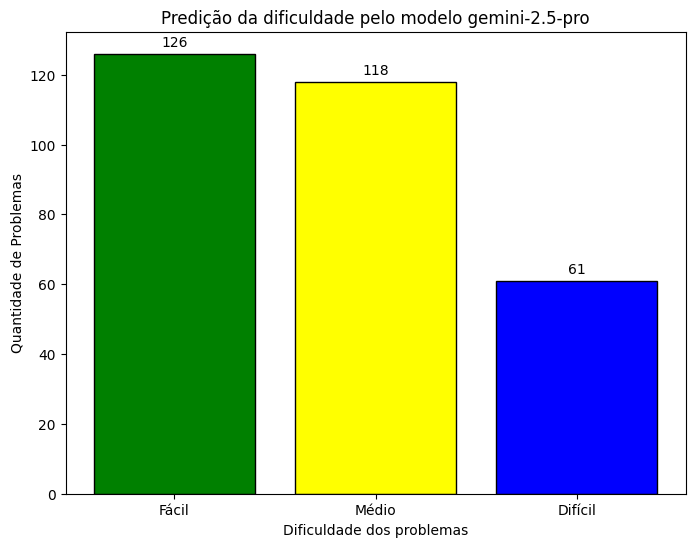

In [54]:
X = ["Fácil", "Médio", "Difícil"]
y = [counts_difficulty[x] for x in X]

print(y)
print(X)
plt.figure(figsize=(8, 6))

bar_plot = plt.bar(X, y, color=['green', 'yellow', 'blue'], edgecolor='black')

plt.bar_label(bar_plot, padding=3)

plt.title("Predição da dificuldade pelo modelo gemini-2.5-pro")
plt.ylabel('Quantidade de Problemas')
plt.xlabel('Dificuldade dos problemas')
plt.show()

### Estatísticas do Judge

---

In [47]:
def average(data):
    n = len(data)
    count = 0
    
    for value in data:
        count += value
        
    return float(count/n)

In [48]:
def per_ac_questions(data):
    n = len(data)
    count = 0
    for value in data["judge_predict"]:
        if value == "AC":
            count += 1
            
    return float(count/n)

In [49]:
files_path = Path("../output/results/")

dataset = {}

for path in list(files_path.rglob('*')):
    model = str(path).split("results_")[1]
    model = model.split("_python_few")[0]
    
    dataset[model] = pd.read_csv(path)

In [50]:
metrics = {}

for key, data in dataset.items():
    
    row = {}
    
    hard_questions = data[data["difficulty"] == "Difícil"]
    row['hard_ac'] = per_ac_questions(hard_questions)
    
    medium_questions = data[data["difficulty"] == "Médio"]
    row['medium_ac'] = per_ac_questions(medium_questions)
    
    easy_questions = data[data["difficulty"] == "Fácil"]
    row['easy_ac'] = per_ac_questions(easy_questions)
    
    row['avg_tokens'] = average(data["total_tokens"])
    row['avg_cost'] = average(data["cost_prompt"])
    row['avg_create_code'] = average(data["llm_code_creation_time"])
    
    metrics[key] = row

In [54]:
print("modelo           | hard ac | medium ac | easy ac | avgTokens | avgCost | avgTimeCreateCode")
for key, data in metrics.items():
    print(f"{key} | {data["hard_ac"]:.2f} | {data["medium_ac"]:.2f} | {data["easy_ac"]:.2f} | {data["avg_tokens"]:.2f} | {data["avg_cost"]:.2f} | {data["avg_create_code"]:.2f}")

modelo           | hard ac | medium ac | easy ac | avgTokens | avgCost | avgTimeCreateCode
gpt_5_4_2026_03_05 | 0.41 | 0.69 | 0.90 | 1498.78 | 0.01 | 3.17
deepseek_deepseek_v3_2 | 0.38 | 0.61 | 0.84 | 1769.43 | 0.00 | 22.04
gemini_3_1_pro_preview | 0.98 | 0.94 | 0.97 | 1702.59 | 0.01 | 48.73


In [53]:
for key, data in dataset.items():
    total_tokens_cases = 0

    for count_test in data["total_tokens"]:
        total_tokens_cases += count_test
        
    print(f"Total de tokens [{key}]: {total_tokens_cases}")

Total de tokens [gpt_5_4_2026_03_05]: 457127
Total de tokens [deepseek_deepseek_v3_2]: 214101
Total de tokens [gemini_3_1_pro_preview]: 410323


In [55]:
for key, data in dataset.items():
    total_time = 0

    for time in data["llm_code_creation_time"]:
        total_time += time
        
    total_time = int(total_time)
    seg = total_time % 60
    total_time = total_time - seg
    total_time = total_time / 60 # total_time em minutos
    
    h = total_time / 60
    min = total_time % 60
    
    print(f"Tem de resolução das questões pelo modelo {key}: {int(h)}h {int(min)} min {seg}s")

Tem de resolução das questões pelo modelo gpt_5_4_2026_03_05: 0h 16 min 5s
Tem de resolução das questões pelo modelo deepseek_deepseek_v3_2: 0h 44 min 26s
Tem de resolução das questões pelo modelo gemini_3_1_pro_preview: 3h 15 min 43s


In [60]:
total = 0

for key, data in dataset.items():
    total_cost = 0

    for count_test in data["cost_prompt"]:
        total_cost += count_test
    
    total += total_cost
    
    print(f"Total de tokens [{key}]: U$ {total_cost:.2f}")
    
print(f"Valor gasto atualmente: U$ {total:.2f}")

Total de tokens [gpt_5_4_2026_03_05]: U$ 1.98
Total de tokens [deepseek_deepseek_v3_2]: U$ 0.07
Total de tokens [gemini_3_1_pro_preview]: U$ 1.45
Valor gasto atualmente: U$ 3.50
